In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error
%matplotlib inline

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv')

df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [ ]:
watchlist = [(dtrain, 'train'), (dval, 'val')]


xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

evals_result = {}
model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist,
                  evals_result=evals_result)


In [4]:
df.describe().round()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,num_doors,fuel_efficiency_mpg
count,9704.0,9222.0,8996.0,9704.0,8774.0,9704.0,9202.0,9704.0
mean,200.0,4.0,150.0,3001.0,15.0,2011.0,-0.0,15.0
std,49.0,2.0,30.0,498.0,3.0,7.0,1.0,3.0
min,10.0,0.0,37.0,953.0,6.0,2000.0,-4.0,6.0
25%,170.0,3.0,130.0,2666.0,13.0,2006.0,-1.0,13.0
50%,200.0,4.0,149.0,2993.0,15.0,2012.0,0.0,15.0
75%,230.0,5.0,170.0,3335.0,17.0,2017.0,1.0,17.0
max,380.0,13.0,271.0,4739.0,24.0,2023.0,4.0,26.0


In [5]:
for c in df.columns:
    df[c] = df[c].fillna(0)

In [6]:
df.describe().round()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,num_doors,fuel_efficiency_mpg
count,9704.0,9704.0,9704.0,9704.0,9704.0,9704.0,9704.0,9704.0
mean,200.0,4.0,139.0,3001.0,14.0,2011.0,-0.0,15.0
std,49.0,2.0,48.0,498.0,5.0,7.0,1.0,3.0
min,10.0,0.0,0.0,953.0,0.0,2000.0,-4.0,6.0
25%,170.0,2.0,124.0,2666.0,13.0,2006.0,-1.0,13.0
50%,200.0,4.0,146.0,2993.0,15.0,2012.0,0.0,15.0
75%,230.0,5.0,168.0,3335.0,16.0,2017.0,1.0,17.0
max,380.0,13.0,271.0,4739.0,24.0,2023.0,4.0,26.0


In [21]:
df_full_train, df_test = train_test_split(df,test_size=0.2,random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25,random_state=1)


df_train.reset_index(drop=True)
df_val.reset_index(drop=True)
df_test.reset_index(drop=True)
df_full_train.reset_index(drop=True)

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values


del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [22]:
train_dicts = df_train.to_dict(orient='records')
dv = DictVectorizer(sparse= False)
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)


In [23]:
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
#  Q1
print(export_text(dt, feature_names=list(dv.get_feature_names_out())))


|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



In [28]:
#Q2
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train,y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
y_pred_val = rf.predict(X_val)
mse = mean_squared_error(y_val, y_pred_val)
rmse = np.sqrt(mse)
rmse

np.float64(0.4599777557336149)

In [ ]:
#Q3
scores = []
for r in range(10,201,10):
    rf = RandomForestRegressor(n_estimators=r, random_state=1)
    rf.fit(X_train,y_train)
    y_pred = rf.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    scores.append((r,rmse))


In [36]:
columns = ['n_estimators', 'rmse']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores

,n_estimators,rmse
0,10,0.459978
1,20,0.453659
2,30,0.450743
3,40,0.448007
4,50,0.446151
5,60,0.445266
6,70,0.444610
7,80,0.444893
8,90,0.444724
9,100,0.444318


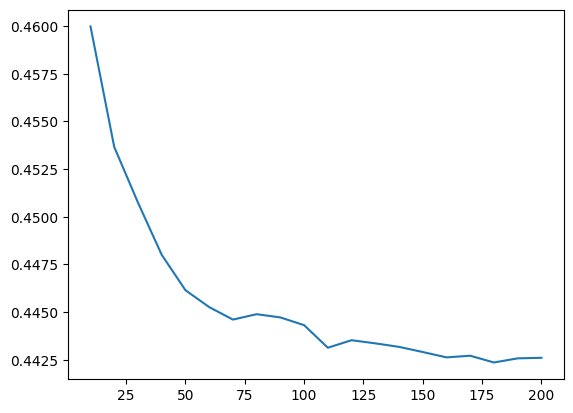

In [37]:
plt.plot(df_scores.n_estimators, df_scores.rmse)

In [39]:
#Q4
scores = []
for n in [10, 15, 20, 25]:
    for r in range(10,201,10):
        rf = RandomForestRegressor(n_estimators=r,max_depth=n, random_state=1)
        rf.fit(X_train,y_train)
        y_pred = rf.predict(X_val)
        mse = mean_squared_error(y_val, y_pred)
        rmse = np.sqrt(mse)
        scores.append((n,r,rmse))

In [ ]:
columns = ['max_depth','n_estimators', 'rmse']
df_scores = pd.DataFrame(scores, columns=columns)

# Promedio de los rmse 
df_mean_rmse = df_scores.groupby('max_depth')['rmse'].mean()
df_mean_rmse = df_mean_rmse.reset_index()

df_mean_rmse.columns = ['max_depth', 'mean_rmse']

df_mean_rmse


,max_depth,mean_rmse
0,10,0.442321
1,15,0.445060
2,20,0.445644
3,25,0.445661


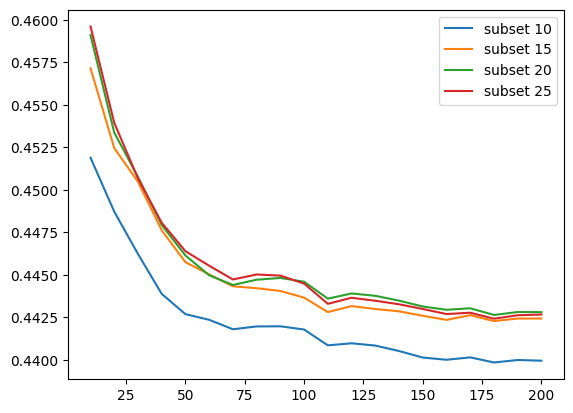

In [41]:
for n in [10, 15, 20, 25]:
    df_subset = df_scores[df_scores.max_depth == n]
    plt.plot(df_subset.n_estimators, df_subset.rmse, label= f'subset {n}')
    plt.legend()

In [ ]:
# Q5
rf = RandomForestRegressor(n_estimators=10,
                            max_depth=20,
                            random_state=1,
                            n_jobs=-1 )

rf.fit(X_train,y_train)

importance_features = rf.feature_importances_
name_features= dv.get_feature_names_out()

df_importances = pd.Series(importance_features, index=name_features).sort_values(ascending=False)

df_importances


vehicle_weight                  0.959162
horsepower                      0.016040
acceleration                    0.011471
engine_displacement             0.003269
model_year                      0.003182
num_cylinders                   0.002359
num_doors                       0.001591
origin=USA                      0.000555
origin=Europe                   0.000520
origin=Asia                     0.000476
drivetrain=All-wheel drive      0.000382
fuel_type=Diesel                0.000344
fuel_type=Gasoline              0.000337
drivetrain=Front-wheel drive    0.000312
dtype: float64

In [47]:
#Q6

import xgboost as xgb

features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [ ]:
scores= {}

In [68]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

xgb_params = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,
        
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

evals_result = {}

model = xgb.train(xgb_params, dtrain, num_boost_round=100,
                  verbose_eval=5,
                  evals=watchlist,
                  evals_result=evals_result)

[0]	train-rmse:2.28944	val-rmse:2.34561
[5]	train-rmse:1.41247	val-rmse:1.44988
[10]	train-rmse:0.91008	val-rmse:0.94062
[15]	train-rmse:0.63402	val-rmse:0.66672
[20]	train-rmse:0.48983	val-rmse:0.53064
[25]	train-rmse:0.41881	val-rmse:0.46891
[30]	train-rmse:0.38342	val-rmse:0.44289
[35]	train-rmse:0.36435	val-rmse:0.43250
[40]	train-rmse:0.35343	val-rmse:0.42746
[45]	train-rmse:0.34621	val-rmse:0.42595
[50]	train-rmse:0.33998	val-rmse:0.42498
[55]	train-rmse:0.33480	val-rmse:0.42449
[60]	train-rmse:0.33054	val-rmse:0.42456
[65]	train-rmse:0.32602	val-rmse:0.42493
[70]	train-rmse:0.32202	val-rmse:0.42503
[75]	train-rmse:0.31895	val-rmse:0.42526
[80]	train-rmse:0.31667	val-rmse:0.42563
[85]	train-rmse:0.31440	val-rmse:0.42574
[90]	train-rmse:0.31059	val-rmse:0.42586
[95]	train-rmse:0.30625	val-rmse:0.42611
[99]	train-rmse:0.30419	val-rmse:0.42623


In [69]:
def get_xgb_scores(evals_result):
    train_aucs = list(evals_result['train'].values())[0]
    val_aucs = list(evals_result['val'].values())[0]

    # Definimos los nombres de las columnas
    columns = ['iter', 'train', 'val']

    # Creamos un DataFrame combinando la lista de iteraciones, train_aucs y val_aucs
    df_results = pd.DataFrame(
        list(zip(
            # Generamos la columna de iteración (desde 1 hasta el final)
            range(1, len(train_aucs) + 1),
            train_aucs,
            val_aucs
        )), 
        columns=columns
    )
    
    return df_results

In [70]:
key = f'eta={xgb_params['eta']}'
scores[key] = get_xgb_scores(evals_result)
key
scores

{'eta=0.3':     iter     train       val
 0      1  1.813927  1.854443
 1      2  1.319193  1.353529
 2      3  0.981204  1.013162
 3      4  0.754432  0.786667
 4      5  0.606796  0.643181
 ..   ...       ...       ...
 95    96  0.224749  0.449043
 96    97  0.223360  0.449539
 97    98  0.221308  0.449793
 98    99  0.220135  0.450396
 99   100  0.219502  0.450178
 
 [100 rows x 3 columns],
 'eta=0.1':     iter     train       val
 0      1  2.289439  2.345608
 1      2  2.073956  2.124343
 2      3  1.880660  1.925969
 3      4  1.707302  1.749867
 4      5  1.551633  1.590589
 ..   ...       ...       ...
 95    96  0.306248  0.426105
 96    97  0.305653  0.426213
 97    98  0.305568  0.426295
 98    99  0.304856  0.426292
 99   100  0.304186  0.426228
 
 [100 rows x 3 columns]}

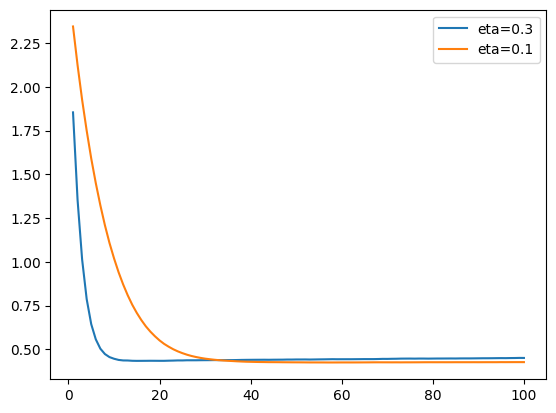

In [72]:
for eta, df_result in scores.items():
    plt.plot(df_result.iter, df_result.val, label=eta)

plt.legend()
